In [22]:
!curl https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv --output pima-indians-diabetes.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 23278  100 23278    0     0   127k      0 --:--:-- --:--:-- --:--:--  127k


In [23]:
# import keras
from keras.models import Sequential
from keras.layers import Dense
import numpy

In [24]:
seed = 7
numpy.random.seed(seed)

dataset = numpy.loadtxt("pima-indians-diabetes.csv", delimiter=',')

#X = dataset[:,0:8]
#Y = dataset[:,8]

x_train = dataset[0:667,0:8]
y_train = dataset[0:667,8:9]
x_test = dataset[667:777,0:8]
y_test = dataset[667:777,8:9]

In [25]:
dataset.shape

#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#x_train= scaler.fit_transform(x_train)
#x_test= scaler.transform(x_test)

(768, 9)

In [26]:
model = Sequential()
model.add(Dense(6, input_dim=8, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=150, batch_size=10, validation_split=0.7)

Epoch 1/150


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6304 - loss: 1.3301 - val_accuracy: 0.6702 - val_loss: 1.7644
Epoch 2/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6888 - loss: 1.3456 - val_accuracy: 0.6681 - val_loss: 1.3076
Epoch 3/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6058 - loss: 0.9165 - val_accuracy: 0.6638 - val_loss: 1.0784
Epoch 4/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5929 - loss: 0.8766 - val_accuracy: 0.6660 - val_loss: 0.9764
Epoch 5/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6281 - loss: 0.6722 - val_accuracy: 0.6617 - val_loss: 0.8977
Epoch 6/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6128 - loss: 0.6692 - val_accuracy: 0.6617 - val_loss: 0.8304
Epoch 7/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6754 - loss: 0.6518 - val_accuracy: 0.6617 - val_loss: 0.8064
Epoch 8/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6397 - loss: 0.6508 - val_accuracy: 0.6638 - val_loss: 0.

In [27]:
scores = model.evaluate(x_test, y_test)
print("%s: %.2f%%" % (model.metrics_names[0], scores[0]*100))
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6349 - loss: 0.6602 
loss: 67.01%
compile_metrics: 62.38%


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


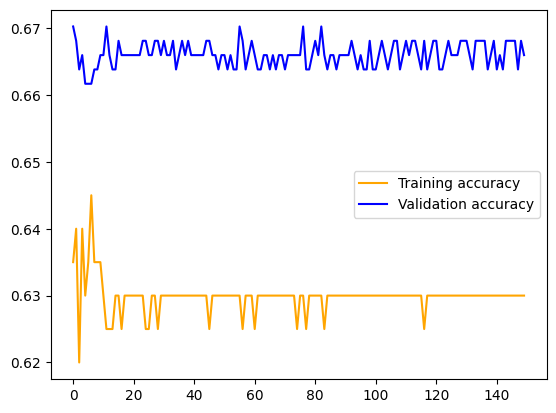

In [28]:
import matplotlib.pyplot as plt

print(history.history.keys())

plt.figure()
plt.plot(history.history['accuracy'], 'orange', label='Training accuracy')
plt.plot(history.history['val_accuracy'], 'blue', label='Validation accuracy')
#plt.plot(history.history['loss'], 'red', label='Training loss')
#plt.plot(history.history['val_loss'], 'green', label='Validation loss')
plt.legend()
plt.show()

In [29]:
new_patient = numpy.array([[2, 197, 70, 45, 543, 30.5, 0.158, 53]])
prediction = model.predict(new_patient)
if prediction > 0.5:
    print("The patient is predicted to be sick.")
else:
    print("The patient is predicted to be healthy.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
The patient is predicted to be healthy.
